## Установка и импорт зависимостей

In [1]:
%%capture
!pip install transformers datasets pandas matplotlib

In [2]:
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer
import pandas as pd
import matplotlib.pyplot as plt

## Загрузка и знакомство с данными

In [3]:
ds = load_dataset("sagteam/cedr_v1")
train_df = pd.DataFrame(ds['train'])

print("Размер выборки:", train_df.shape)
print("Столбцы:", train_df.columns.tolist())
print("Типы данных:")
print(train_df.dtypes)
display(train_df.head())

Размер выборки: (7528, 3)
Столбцы: ['text', 'labels', 'source']
Типы данных:
text      object
labels    object
source    object
dtype: object


,text,labels,source
0,Суровый гималайский медведь .,[],lj
1,"Так, обнаружено несколько проблем с дисплеем (...",[],lenta
2,У меня остается только один вопрос - является ...,[2],lj
3,Забавно как люди в возрасте удивляются входящи...,[0],twitter
4,"Издание The Register отмечает, что у владельце...",[],lenta


### Целевая переменная

Расшифровка label
- 0: "joy", 
- 1: "sadness", 
- 2: "surprise", 
- 3: "fear", 
- 4: "anger"

In [4]:
label_counts = train_df['labels'].value_counts()
label_counts

labels
[]           3043
[0]          1508
[1]          1365
[2]           568
[3]           553
[4]           384
[0, 2]         27
[1, 4]         13
[1, 3]         12
[1, 0]          9
[0, 3]          6
[3, 0]          6
[0, 1]          5
[3, 4]          4
[3, 1]          4
[3, 2]          3
[4, 0]          3
[4, 1]          3
[1, 2]          3
[2, 0]          2
[2, 1]          2
[0, 4]          2
[1, 4, 0]       1
[2, 3]          1
[2, 4]          1
Name: count, dtype: int64

In [5]:
multilabel_count = (train_df['labels'].str.len() > 1).sum()
total_count = len(train_df)
print(f"Всего записей: {total_count}")
print(f"Из них имеют несколько меток: {multilabel_count} ({multilabel_count/total_count*100:.1f}%)")

Всего записей: 7528
Из них имеют несколько меток: 107 (1.4%)


Имеем 3043 строк без метки, нужно изучить на нейтральность эмоциональной окраски. </br>
Также имеем 107 строк с несколькими метками, которые составляют 1.4% от всей выборки. Такие строки удаляем из обучающей выборки, оставляем только строки с однозначной целевой переменной

### Целевая переменная без метки

In [6]:
pd.set_option('display.max_colwidth', None)
neutral_texts = train_df[train_df['labels'].str.len() == 0]['text']
neutral_texts.head(50)

0                                                                                                                                                                                       Суровый гималайский медведь .
1                                                                                  Так, обнаружено несколько проблем с дисплеем (выгорание, странные зеленые полосы), дефекты динамика и некорректная работа Face ID.
4                     Издание The Register отмечает, что у владельцев гаджетов пока нет повода для паники из-за уязвимости батареи, потому что пока атака остается лишь теорией, которую попытались проверить ученые.
10                                                                               Ей пригрозили пятилетним запретом на въезд в страну и сказали, что не могут ее отпустить, так она попала на запись камер наблюдения.
11                                                                                                                                     Как прави

In [7]:
pd.reset_option('display.max_colwidth')

Содержимое текстов без метки представляет собой новостной контент и утверждения без эмоциональной окраски, то есть установим для таких строк эмоциональную окраску как нейтральную

## Подготовка данных

Итоговый label
- 0: "joy (радость)", 
- 1: "sadness (грусть)", 
- 2: "surprise (удивление)", 
- 3: "fear (страх)", 
- 4: "anger (гнев)",
- 5: "neutral (нейтрально)"

In [8]:
train_clean = train_df[train_df['labels'].str.len() <= 1].copy()

train_clean['label'] = train_clean['labels'].apply(
    lambda x: 5 if len(x) == 0 else x[0]
)

train_clean = train_clean[['text', 'label']]
train_clean.head()

,text,label
0,Суровый гималайский медведь .,5
1,"Так, обнаружено несколько проблем с дисплеем (...",5
2,У меня остается только один вопрос - является ...,2
3,Забавно как люди в возрасте удивляются входящи...,0
4,"Издание The Register отмечает, что у владельце...",5


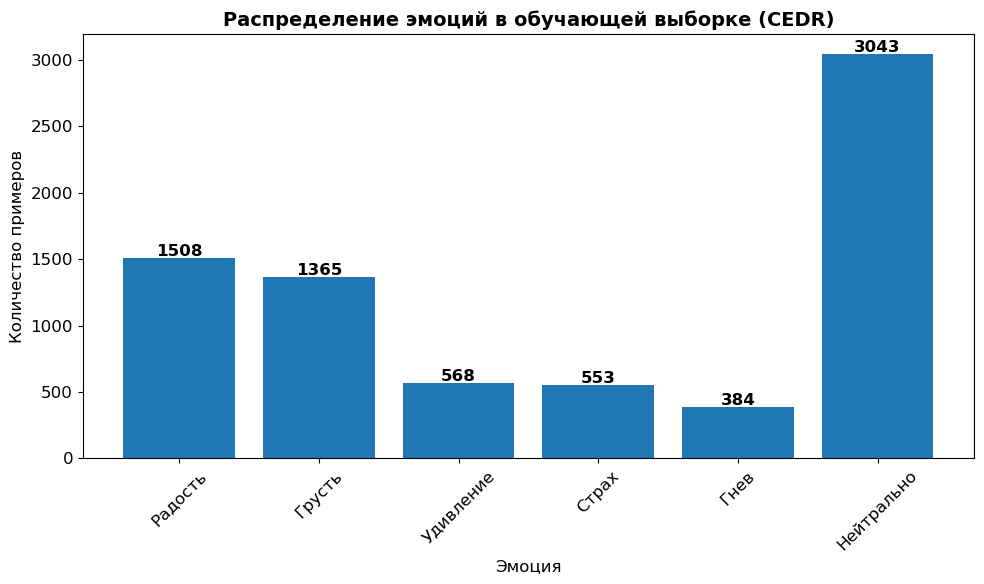

In [9]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

emotion_names = {
    0: 'Радость',
    1: 'Грусть',
    2: 'Удивление',
    3: 'Страх',
    4: 'Гнев',
    5: 'Нейтрально'
}

class_counts = train_clean['label'].value_counts().sort_index()

bars = plt.bar(
    [emotion_names[i] for i in class_counts.index],
    class_counts.values,
    linewidth=0.5
)

for bar, count in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        str(count),
        ha='center',
        fontweight='bold'
    )

plt.title('Распределение эмоций в обучающей выборке (CEDR)', fontsize=14, fontweight='bold')
plt.xlabel('Эмоция')
plt.ylabel('Количество примеров')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Токенизация и сохранение

Переводим текст в токены, понятные BERT. </br>
Используем `DeepPavlov/rubert-base-cased` русскоязычный BERT для классификации коротких текстов на русском.

In [10]:
tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

ds = Dataset.from_pandas(train_clean[["text", "label"]])
tokenized_ds = ds.map(tokenize_function, batched=True)
tokenized_ds = tokenized_ds.remove_columns(["text"])
tokenized_ds.save_to_disk("data/tokenized_cedr")

Map:   0%|          | 0/7421 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7421 [00:00<?, ? examples/s]